In [1]:
%load_ext autoreload
%autoreload 2

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import distance_matrix
import torch
from torch.utils.data import DataLoader

In [ ]:
from mapcharting.dataset.dataset import CSIPairsDataset
from mapcharting.dissimilarity.dissimilarity import adp_dissimilarity, timestamp_dissimilarity, geodesic_dissimilarity
from mapcharting.loss.loss import siamese_loss
from mapcharting.model.model import ChannelCharter

In [4]:
csi = np.load("data/csi.npz")["arr_0"]
timestamps = np.load("data/timestamps.npz")["arr_0"]
positions = np.load("data/positions.npz")["arr_0"]

In [5]:
device = "mps"
adp_dissimilarity_matrix = adp_dissimilarity(csi, device=device)

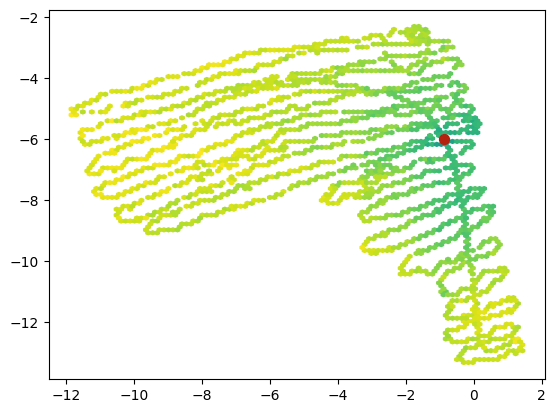

In [6]:
POS = 100

# Hexagonal grid plotting with mp's hexbin
plt.hexbin(positions[:,0], positions[:,1], C=adp_dissimilarity_matrix[POS,:])

# We also mark the position of the reference point
plt.scatter(positions[POS,0], positions[POS,1], s=50, c="#b42210")

In [7]:
timestamp_dissimilarity_matrix = np.abs(np.subtract.outer(timestamps, timestamps))

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/w6/676x2xcs0vq7hd8pshvhxgdm0000gn/T/ipykernel_38486/306587099.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")
/var/folders/w6/676x2xcs0vq7hd8pshvhxgdm0000gn/T/ipykernel_38486/306587099.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  occurences, edges, patches = ax1.hist(small_adp_dissimilarities / small_time_dissimilarities, range = (0, 50), bins = n_bins)


Text(0, 0.5, 'Number of Occurences')

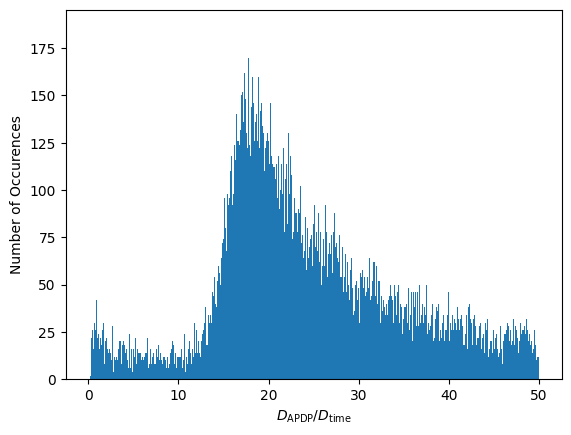

In [8]:
TIME_THRESHOLD = 2
small_time_dissimilarity_indices = np.logical_and(timestamp_dissimilarity_matrix < TIME_THRESHOLD, timestamp_dissimilarity_matrix > 0)
small_time_dissimilarities = timestamp_dissimilarity_matrix[small_time_dissimilarity_indices]
small_adp_dissimilarities = adp_dissimilarity_matrix[small_time_dissimilarity_indices]

n_bins = 1500

fig, ax1 = plt.subplots()
occurences, edges, patches = ax1.hist(small_adp_dissimilarities / small_time_dissimilarities, range = (0, 50), bins = n_bins)
ax1.set_xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")
ax1.set_ylabel("Number of Occurences")

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/w6/676x2xcs0vq7hd8pshvhxgdm0000gn/T/ipykernel_38486/4030542455.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")


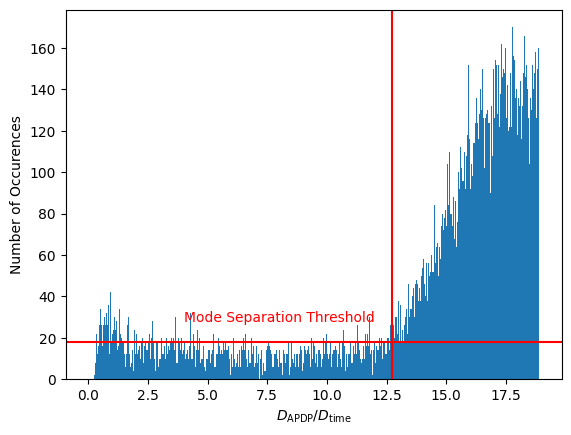

gamma =  12.71666669845581


In [9]:
bin_centers = edges[:-1] + np.diff(edges) / 2.
max_bin = np.argmax(occurences)
min_threshold = np.quantile(occurences[:max_bin], 0.5)

for threshold_bin in range(max_bin - 1, -1, -1):
	if occurences[threshold_bin] < min_threshold:
		break

scaling_factor = bin_centers[threshold_bin]

plt.bar(bin_centers[:max_bin], occurences[:max_bin], width = edges[1] - edges[0])
plt.axhline(y = min_threshold, color = 'r', linestyle = '-')
plt.text(4, min_threshold + 10, "Mode Separation Threshold", color = 'r',)
plt.axvline(x = scaling_factor, color = 'r', linestyle = '-')
plt.xlabel("$D_\mathrm{APDP} / D_\mathrm{time}$")
plt.ylabel("Number of Occurences")
plt.show()

print("gamma = ", scaling_factor)

In [10]:
dissimilarity_matrix_fused = np.minimum(adp_dissimilarity_matrix, timestamp_dissimilarity_matrix * scaling_factor)

/var/folders/w6/676x2xcs0vq7hd8pshvhxgdm0000gn/T/ipykernel_38486/338179116.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  dissimilarity_matrix_fused = np.minimum(adp_dissimilarity_matrix, timestamp_dissimilarity_matrix * scaling_factor)


In [11]:
dissimilarity_matrix_geodesic = geodesic_dissimilarity(dissimilarity_matrix=dissimilarity_matrix_fused)

100%|██████████| 4629/4629 [00:12<00:00, 370.85it/s]


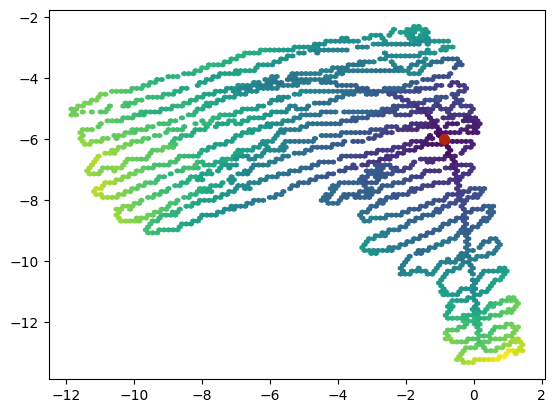

In [12]:
POS = 100

# Hexagonal grid plotting with mp's hexbin
plt.hexbin(positions[:,0], positions[:,1], C=dissimilarity_matrix_geodesic[POS,:])

# We also mark the position of the reference point
plt.scatter(positions[POS,0], positions[POS,1], s=50, c="#b42210")

In [13]:
groundtruth_distance_matrix = distance_matrix(positions, positions)
groundtruth_distance_matrix.shape

(4629, 4629)

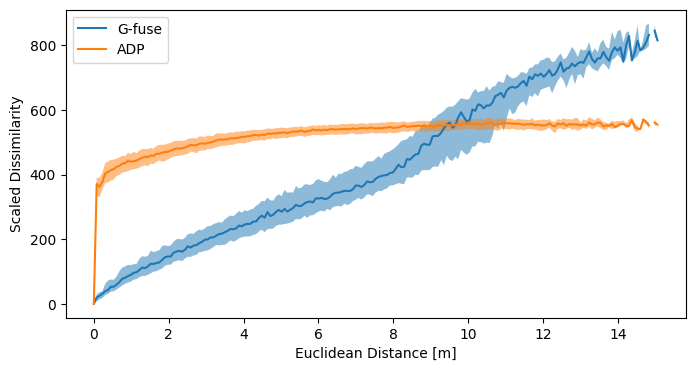

In [15]:
def plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix, distance_matrix, label = None):
	nth_reduction = 10
	dissimilarities_flat = dissimilarity_matrix[::nth_reduction, ::nth_reduction].flatten()
	distances_flat = distance_matrix[::nth_reduction, ::nth_reduction].flatten()
	
	max_distance = np.max(distances_flat)
	bins = np.linspace(0, max_distance, 200)
	bin_indices = np.digitize(distances_flat, bins)
	
	bin_medians = np.zeros(len(bins) - 1)
	bin_25_perc = np.zeros(len(bins) - 1)
	bin_75_perc = np.zeros(len(bins) - 1)
	for i in range(1, len(bins)):
		bin_values = dissimilarities_flat[bin_indices == i]
		if len(bin_values) == 0:                                                                                                                                                                        
			bin_25_perc[i - 1] = bin_medians[i - 1] = bin_75_perc[i - 1] = np.nan                                                                                                                       
			continue                                                                                                                                                                                    
		bin_25_perc[i - 1], bin_medians[i - 1], bin_75_perc[i - 1] = np.percentile(bin_values, [25, 50, 75]) 
	
	plt.plot(bins[:-1], bin_medians, label = label)
	plt.fill_between(bins[:-1], bin_25_perc, bin_75_perc, alpha=0.5)
		
plt.figure(figsize=(8,4))

plot_dissimilarity_over_euclidean_distance(dissimilarity_matrix_geodesic, groundtruth_distance_matrix, "G-fuse")
plot_dissimilarity_over_euclidean_distance(scaling_factor * adp_dissimilarity_matrix, groundtruth_distance_matrix, "ADP")

plt.legend()
plt.xlabel("Euclidean Distance [m]")
plt.ylabel("Scaled Dissimilarity")
plt.show()

In [ ]:
batch_size = 128
csi_dataset = CSIPairsDataset(csi, dissimilarity_matrix_geodesic)
train_loader = DataLoader(csi_dataset, batch_size=batch_size)

In [30]:
learning_rate = 1e-4
epochs = 100

model = ChannelCharter()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for i in range(epochs):
    running_loss = 0
    for csi_a, csi_b, dissimilarity in train_loader:
        optimizer.zero_grad()

        oa = model(csi_a)
        ob = model(csi_b)

        loss = siamese_loss(oa, ob, dissimilarity)
        loss.backward()

        running_loss += loss.item()

        optimizer.step()

    if i % 5 == 0:
        print(f"Epoch: {i} - Loss: {running_loss}")



RuntimeError: mat1 and mat2 shapes cannot be multiplied (1703936x2 and 2000x1024)